# Syneco data sanity checks

### Check if the first preprocessing passed

Used script to combine the metadata and pv output csvs: preprocess_germany_pv.py

In [1]:
import os
import pandas as pd

# Navigate to project root if in notebooks directory
if os.getcwd().endswith('notebooks') or os.getcwd().endswith('data_cleaning'):
    while not os.path.exists('data'):
        os.chdir('..')

df = pd.read_parquet("data/interim/germany/plant_01_pv_15min.parquet")
print(df.head())
print(df.tail())
print(df.describe())

              timestamp_utc  power_kw  power_w  power_norm
0 2022-12-31 23:00:00+00:00       0.0      0.0         0.0
1 2022-12-31 23:15:00+00:00       0.0      0.0         0.0
2 2022-12-31 23:30:00+00:00       0.0      0.0         0.0
3 2022-12-31 23:45:00+00:00       0.0      0.0         0.0
4 2023-01-01 00:00:00+00:00       0.0      0.0         0.0
                  timestamp_utc  power_kw  power_w  power_norm
61431 2024-10-01 20:45:00+00:00       0.0      0.0         0.0
61432 2024-10-01 21:00:00+00:00       0.0      0.0         0.0
61433 2024-10-01 21:15:00+00:00       0.0      0.0         0.0
61434 2024-10-01 21:30:00+00:00       0.0      0.0         0.0
61435 2024-10-01 21:45:00+00:00       0.0      0.0         0.0
           power_kw        power_w    power_norm
count  61434.000000   61434.000000  61434.000000
mean      70.967557   70967.556793      0.095118
std      128.480774  128480.774098      0.172203
min        0.000000       0.000000      0.000000
25%        0.000000    

## Global Sanity check for all six plants

In [2]:
import os
from pathlib import Path

import pandas as pd

# Move to repo root if you are in notebooks/ or similar
while not Path("data").exists() and Path.cwd().name != "pv_forecast_30d":
    os.chdir("..")

print("CWD:", Path.cwd())

plant_ids = ["plant_01", "plant_02", "plant_03", "plant_04", "plant_05", "plant_06"]
base_path = Path("data/interim/germany")

def summarize_plant(pid: str):
    path = base_path / f"{pid}_pv_15min.parquet"
    df = pd.read_parquet(path)
    print(f"\n===== {pid} =====")
    print(f"rows: {len(df)}")
    print(df.head(3))
    print(df.tail(3))

    # 1) timestamp type and UTC check
    ts = df["timestamp_utc"]
    print("timestamp dtype:", ts.dtype)
    has_tz = getattr(ts.dt.tz, "key", None)
    print("timezone:", has_tz)

    # 2) check time deltas and missing steps
    df = df.sort_values("timestamp_utc")
    ts = df["timestamp_utc"]
    diffs = ts.diff().dropna()

    # dominant delta
    delta_counts = diffs.value_counts().sort_values(ascending=False)
    dominant_delta = delta_counts.index[0]
    print("dominant time step:", dominant_delta)

    # expected freq if we assume 15 min
    full_index = pd.date_range(ts.min(), ts.max(), freq="15min", tz=ts.dt.tz)
    missing = full_index.difference(ts)
    print("expected points at 15min:", len(full_index))
    print("actual points:", len(ts))
    print("missing timestamps (15min grid):", len(missing))

    # 3) NaN check
    print("NaNs per column:")
    print(df.isna().sum())

    # 5) basic stats
    print("power_kw stats:")
    print(df["power_kw"].describe())
    print("power_norm stats:")
    print(df["power_norm"].describe())

for pid in plant_ids:
    summarize_plant(pid)


CWD: /home/dwijenayake/pv_forecast_30d

===== plant_01 =====
rows: 61436
              timestamp_utc  power_kw  power_w  power_norm
0 2022-12-31 23:00:00+00:00       0.0      0.0         0.0
1 2022-12-31 23:15:00+00:00       0.0      0.0         0.0
2 2022-12-31 23:30:00+00:00       0.0      0.0         0.0
                  timestamp_utc  power_kw  power_w  power_norm
61433 2024-10-01 21:15:00+00:00       0.0      0.0         0.0
61434 2024-10-01 21:30:00+00:00       0.0      0.0         0.0
61435 2024-10-01 21:45:00+00:00       0.0      0.0         0.0
timestamp dtype: datetime64[ns, UTC]
timezone: None
dominant time step: 0 days 00:15:00
expected points at 15min: 61436
actual points: 61436
missing timestamps (15min grid): 0
NaNs per column:
timestamp_utc    0
power_kw         2
power_w          2
power_norm       2
dtype: int64
power_kw stats:
count    61434.000000
mean        70.967557
std        128.480774
min          0.000000
25%          0.000000
50%          0.000000
75%      

## Visual check of curves for summer and winter days

In [3]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Make sure you are at repo root
while not Path("data").exists() and Path.cwd().name != "pv_forecast_30d":
    os.chdir("..")

base_path = Path("data/interim/germany")
plant_ids = ["plant_01", "plant_02", "plant_03", "plant_04", "plant_05", "plant_06"]

def plot_summer_winter_grid(summer_date: str, winter_date: str):
    """
    summer_date, winter_date as 'YYYY-MM-DD' in UTC.
    Creates one figure with 6 rows (plants) and 2 columns (summer, winter).
    """
    fig, axes = plt.subplots(
        nrows=len(plant_ids),
        ncols=2,
        figsize=(10, 3 * len(plant_ids)),
        sharex=False,
        sharey=False,
    )

    for i, pid in enumerate(plant_ids):
        path = base_path / f"{pid}_pv_15min.parquet"
        df = pd.read_parquet(path)
        df["date"] = df["timestamp_utc"].dt.date

        for j, (date_str, label) in enumerate(
            [(summer_date, "summer"), (winter_date, "winter")]
        ):
            ax = axes[i, j]
            target_date = pd.to_datetime(date_str).date()
            day = df[df["date"] == target_date]

            if day.empty:
                ax.text(
                    0.5,
                    0.5,
                    f"no data\n{target_date}",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_axis_off()
                continue

            ax.plot(day["timestamp_utc"], day["power_kw"])
            if j == 0:
                ax.set_ylabel(f"{pid}\n[kW]")
            ax.set_title(f"{label} {target_date} UTC")
            ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


#### Plots below ↓

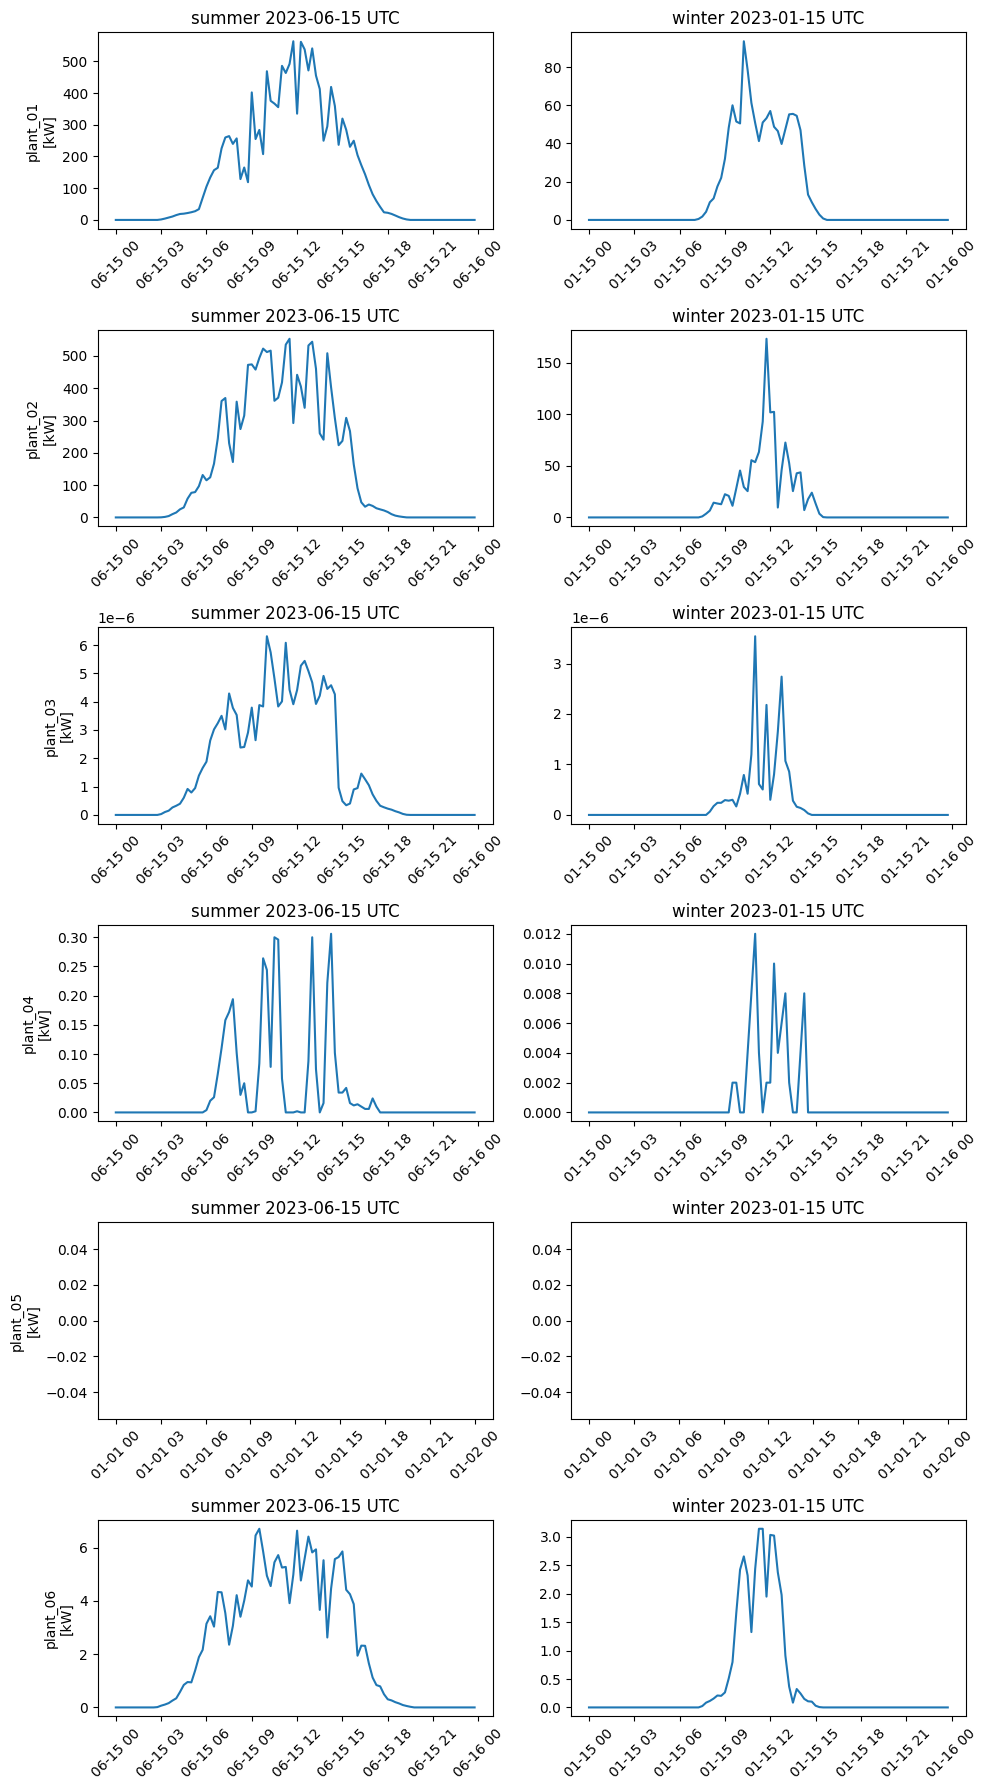

In [4]:
plot_summer_winter_grid("2023-06-15", "2023-01-15")


### Plant 05 has no data on the selected dates
So we isnpect the date range

In [5]:
# Use absolute path to avoid directory confusion
from pathlib import Path

project_root = Path("/home/dwijenayake/pv_forecast_30d")
df = pd.read_parquet(project_root / "data/interim/germany/plant_05_pv_15min.parquet")
print("Date range:", df["timestamp_utc"].min(), "to", df["timestamp_utc"].max())

Date range: 2022-12-31 23:00:00+00:00 to 2024-04-01 21:45:00+00:00


### Notebopok cells to diagnose scaling and coverage

In [6]:
import os, json
from pathlib import Path
import pandas as pd

# move to repo root if needed
while not Path("data").exists() and Path.cwd().name != "pv_forecast_30d":
    os.chdir("..")

base_pv = Path("data/interim/germany")
base_meta = Path("data/metadata/germany")

def inspect_plant(pid: str):
    pv_path = base_pv / f"{pid}_pv_15min.parquet"
    meta_path = base_meta / f"{pid}.json"

    df = pd.read_parquet(pv_path)
    with meta_path.open("r", encoding="utf-8") as f:
        meta = json.load(f)

    cap = meta["installed_capacity_kw"]
    print(f"\n===== {pid} =====")
    print("capacity kW:", cap)
    print("time range:", df["timestamp_utc"].min(), "→", df["timestamp_utc"].max())
    print("rows:", len(df))
    print("power_kw describe:")
    print(df["power_kw"].describe())

    max_kw = df["power_kw"].max()
    ratio = cap / max_kw if max_kw and max_kw != 0 else None
    print("max power_kw:", max_kw)
    print("cap / max_ratio:", ratio)

for pid in ["plant_01", "plant_02", "plant_03", "plant_04", "plant_05", "plant_06"]:
    inspect_plant(pid)



===== plant_01 =====
capacity kW: 746.1
time range: 2022-12-31 23:00:00+00:00 → 2024-10-01 21:45:00+00:00
rows: 61436
power_kw describe:
count    61434.000000
mean        70.967557
std        128.480774
min          0.000000
25%          0.000000
50%          0.000000
75%         79.500000
max        566.000000
Name: power_kw, dtype: float64
max power_kw: 566.0
cap / max_ratio: 1.3181978798586573

===== plant_02 =====
capacity kW: 746.1
time range: 2022-12-31 23:00:00+00:00 → 2024-10-01 21:45:00+00:00
rows: 61432
power_kw describe:
count    61430.000000
mean        86.450540
std        143.589614
min          0.000000
25%          0.000000
50%          1.500000
75%        113.100000
max        564.400000
Name: power_kw, dtype: float64
max power_kw: 564.4
cap / max_ratio: 1.3219347980155918

===== plant_03 =====
capacity kW: 7358.9
time range: 2022-12-31 23:00:00+00:00 → 2024-04-01 21:45:00+00:00
rows: 43868
power_kw describe:
count    3.494500e+04
mean     8.559026e-07
std      1.5393

### Conclusion
Some powerplants are having sane max power values while some do not and when inspecting its visible that they were scaling erros so we follow a rule based scaling logic to scale and overwrite the existing inteprim parquets so they all have the same power norm. For the details look into the doctring on top of the file 
'src/data/fix_germany_pv_scaling.py'

### Recheck the values for the plants

In [7]:
import os, json
from pathlib import Path
import pandas as pd

# move to repo root if needed
while not Path("data").exists() and Path.cwd().name != "pv_forecast_30d":
    os.chdir("..")

base_pv = Path("data/interim/germany")
base_meta = Path("data/metadata/germany")

def inspect_plant(pid: str):
    pv_path = base_pv / f"{pid}_pv_15min.parquet"
    meta_path = base_meta / f"{pid}.json"

    df = pd.read_parquet(pv_path)
    with meta_path.open("r", encoding="utf-8") as f:
        meta = json.load(f)

    cap = meta["installed_capacity_kw"]
    print(f"\n===== {pid} =====")
    print("capacity kW:", cap)
    print("time range:", df["timestamp_utc"].min(), "→", df["timestamp_utc"].max())
    print("rows:", len(df))
    print("power_kw describe:")
    print(df["power_kw"].describe())

    max_kw = df["power_kw"].max()
    ratio = cap / max_kw if max_kw and max_kw != 0 else None
    print("max power_kw:", max_kw)
    print("cap / max_ratio:", ratio)

for pid in ["plant_01", "plant_02", "plant_03", "plant_04", "plant_05", "plant_06"]:
    inspect_plant(pid)



===== plant_01 =====
capacity kW: 746.1
time range: 2022-12-31 23:00:00+00:00 → 2024-10-01 21:45:00+00:00
rows: 61436
power_kw describe:
count    61434.000000
mean        70.967557
std        128.480774
min          0.000000
25%          0.000000
50%          0.000000
75%         79.500000
max        566.000000
Name: power_kw, dtype: float64
max power_kw: 566.0
cap / max_ratio: 1.3181978798586573

===== plant_02 =====
capacity kW: 746.1
time range: 2022-12-31 23:00:00+00:00 → 2024-10-01 21:45:00+00:00
rows: 61432
power_kw describe:
count    61430.000000
mean        86.450540
std        143.589614
min          0.000000
25%          0.000000
50%          1.500000
75%        113.100000
max        564.400000
Name: power_kw, dtype: float64
max power_kw: 564.4
cap / max_ratio: 1.3219347980155918

===== plant_03 =====
capacity kW: 7358.9
time range: 2022-12-31 23:00:00+00:00 → 2024-04-01 21:45:00+00:00
rows: 43868
power_kw describe:
count    34945.000000
mean       907.565067
std       1632.

### Check dominant timestamp delta for all plants

In [8]:
import os
from pathlib import Path
import pandas as pd

# Move to repo root if needed
while not Path("data").exists() and Path.cwd().name != "pv_forecast_30d":
    os.chdir("..")

PV_DIR = Path("data/interim/germany")
plant_ids = ["plant_01", "plant_02", "plant_03", "plant_04", "plant_05", "plant_06"]

def check_freq(pid):
    path = PV_DIR / f"{pid}_pv_15min.parquet"
    df = pd.read_parquet(path)

    df = df.sort_values("timestamp_utc").drop_duplicates(subset=["timestamp_utc"])
    ts = df["timestamp_utc"]

    diffs = ts.diff().dropna()

    # Count dominant time delta
    delta_counts = diffs.value_counts().sort_values(ascending=False)
    dominant = delta_counts.index[0]
    print(f"{pid}: dominant delta = {dominant}, unique deltas = {len(delta_counts)}")
    print(delta_counts.head())
    print()

for pid in plant_ids:
    check_freq(pid)


plant_01: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    61435
Name: count, dtype: int64

plant_02: dominant delta = 0 days 00:15:00, unique deltas = 2
timestamp_utc
0 days 00:15:00    61430
0 days 01:15:00        1
Name: count, dtype: int64

plant_03: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    43867
Name: count, dtype: int64

plant_04: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    61435
Name: count, dtype: int64

plant_05: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    43867
Name: count, dtype: int64

plant_06: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    43867
Name: count, dtype: int64



### Conclusion
Since all powerplants are in 15 min intervals it is safe to enforce a grid of 15min to all data files. 
Note: Only problem is in Plant 02 where there is a 75 min jump which is likely a missing timestamp or missing values which will be fixed form the grid enforcer.

Grid enforcer can be found in 'src/data/enforce_germany_pv_15min_grid.py'

### Recheck if all grids were enforced after the script running ↓↓↓

In [9]:
import os
from pathlib import Path
import pandas as pd

# Move to repo root if needed
while not Path("data").exists() and Path.cwd().name != "pv_forecast_30d":
    os.chdir("..")

PV_DIR = Path("data/interim/germany")
plant_ids = ["plant_01", "plant_02", "plant_03", "plant_04", "plant_05", "plant_06"]

def check_freq(pid):
    path = PV_DIR / f"{pid}_pv_15min.parquet"
    df = pd.read_parquet(path)

    df = df.sort_values("timestamp_utc").drop_duplicates(subset=["timestamp_utc"])
    ts = df["timestamp_utc"]

    diffs = ts.diff().dropna()

    # Count dominant time delta
    delta_counts = diffs.value_counts().sort_values(ascending=False)
    dominant = delta_counts.index[0]
    print(f"{pid}: dominant delta = {dominant}, unique deltas = {len(delta_counts)}")
    print(delta_counts.head())
    print()

for pid in plant_ids:
    check_freq(pid)


plant_01: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    61435
Name: count, dtype: int64

plant_02: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    61435
Name: count, dtype: int64

plant_03: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    43867
Name: count, dtype: int64

plant_04: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    61435
Name: count, dtype: int64

plant_05: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    43867
Name: count, dtype: int64

plant_06: dominant delta = 0 days 00:15:00, unique deltas = 1
timestamp_utc
0 days 00:15:00    43867
Name: count, dtype: int64



## Check date ranges per plant

In [10]:
import json
from pathlib import Path
import pandas as pd

PV_DIR = Path("data/interim/germany")
plant_ids = ["plant_01","plant_02","plant_03","plant_04","plant_05","plant_06"]

date_ranges = {}

for pid in plant_ids:
    df = pd.read_parquet(PV_DIR / f"{pid}_pv_15min.parquet")
    date_ranges[pid] = {
        "start": str(df["timestamp_utc"].min()),
        "end": str(df["timestamp_utc"].max())
    }

date_ranges


{'plant_01': {'start': '2022-12-31 23:00:00+00:00',
  'end': '2024-10-01 21:45:00+00:00'},
 'plant_02': {'start': '2022-12-31 23:00:00+00:00',
  'end': '2024-10-01 21:45:00+00:00'},
 'plant_03': {'start': '2022-12-31 23:00:00+00:00',
  'end': '2024-04-01 21:45:00+00:00'},
 'plant_04': {'start': '2022-12-31 23:00:00+00:00',
  'end': '2024-10-01 21:45:00+00:00'},
 'plant_05': {'start': '2022-12-31 23:00:00+00:00',
  'end': '2024-04-01 21:45:00+00:00'},
 'plant_06': {'start': '2022-12-31 23:00:00+00:00',
  'end': '2024-04-01 21:45:00+00:00'}}

### Sanity check Openmeteo files

In [11]:
import os
from pathlib import Path
import pandas as pd

# make sure we're in repo root
while not Path("data").exists() and Path.cwd().name != "pv_forecast_30d":
    os.chdir("..")

plant_ids = ["plant_01","plant_02","plant_03","plant_04","plant_05","plant_06"]

for pid in plant_ids:
    print(f"\n===== {pid} HOURLY =====")
    h_path = Path(f"data/interim/germany/{pid}/historical_weather_hourly.parquet")
    d_path = Path(f"data/interim/germany/{pid}/historical_weather_daily.parquet")
    print("hourly exists:", h_path.exists(), "daily exists:", d_path.exists())
    if not h_path.exists() or not d_path.exists():
        continue

    df_h = pd.read_parquet(h_path)
    df_d = pd.read_parquet(d_path)

    print("hourly columns:", df_h.columns.tolist())
    print("hourly date range:", df_h["date"].min(), "→", df_h["date"].max())
    print("hourly freq counts (top 3):")
    print(df_h["date"].diff().value_counts().head(3))

    print("\n----- daily -----")
    print("daily columns:", df_d.columns.tolist())
    print("daily date range:", df_d["date"].min(), "→", df_d["date"].max())
    print()



===== plant_01 HOURLY =====
hourly exists: True daily exists: True
hourly columns: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'weather_code', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'shortwave_radiation_instant', 'direct_radiation_instant', 'diffuse_radiation_instant', 'direct_normal_irradiance_instant', 'global_tilted_irradiance_instant', 'surface_pressure', 'date']
hourly date range: 2022-12-31 00:00:00 → 2024-10-01 23:00:00
hourly freq counts (top 3):
date
0 days 01:00:00    15383
Name: count, dtype: int64

----- daily -----
daily columns: ['sunrise', 'sunset', 'daylight_duration', 'sunshine_duration', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'date']
daily date range: 2022-12-31 00:00:00 → 2024-10-01 00:00:00


===== plant_02 HOURLY =====
hourly exists: True daily exists: True
hourly columns: ['temperature_2m', 'relative_humidity_2m', 'precipitation

## Check if the Open meteo Weather data is cvorrect

### Check if the timestamps correct and DST avoided

In [ ]:
import os
from pathlib import Path
import pandas as pd

# make sure we're in repo root
while not Path("data").exists() and Path.cwd().name != "pv_forecast_30d":
    os.chdir("..")

df = pd.read_parquet("data/interim/germany/plant_01_weather_15min.parquet")
print(df["timestamp_utc"].min(), "→", df["timestamp_utc"].max())
print(df["timestamp_utc"].diff().value_counts().head(3))
print("tz:", df["timestamp_utc"].dt.tz)

NameError: name 'Path' is not defined